In [1]:
!pip install HawkesPyLib

# Imports

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pandas as pd
import scipy.stats as stats
from numpy.linalg import inv
import time

from HawkesPyLib.simulation import ExpHawkesProcessSimulation

# 1. Properties of Hawkes MLE estimates 

## Simulation of one dimensional Hawkes Process

**Hawkes process** is a *self-exciting point process* in which the occurrence of an event increases the probability of future events in the short term.

Formally, a Hawkes process is defined by its **conditional intensity function**:
$\lambda(t) = \mu + \int_{0}^{t} \nu(t - s)\, dN(s) = \lambda(t)t + \sum \nu(t - t_i)$

where $\mu$ : $\mathbb{R} \rightarrow \mathbb{R} _+$ and $\nu$ : $\mathbb{R}_+ \rightarrow \mathbb{R}_+$

We define the **simulations parameters** : 

- $\mu$ is the baseline intensity
- $\nu$ is the positive influence of the past events

As we use an exponential kernel in the simulation, we add the parameters $\alpha$ and $\beta$. 

We used values for the parameters defined in the class material to be able to compare our simulation. 

In [2]:
# Parameters
mu = 1.2      # baseline intensity
alpha = 0.6   # excitation parameter
beta = 0.8    # decay parameter
T = 100       # simulation horizon

theta = 1 / beta
eta = alpha / beta

For the process to be stable we need the $\eta$ ratio to be stricly lower than 1. 

In [3]:
print(eta)

0.7499999999999999


In [4]:
hawkes = ExpHawkesProcessSimulation(mu=mu, eta=eta, theta=theta)

In [5]:
events = hawkes.simulate(T, seed=42)

In [6]:
print("Number of events:", len(events))
print("First events:", events[:10])

Number of events: 361
First events: [0.39105674 2.06334643 2.52974061 2.60279308 3.30653735 5.2928917
 5.40573646 5.48259425 5.71872131 5.81952488]


We blot the dashed lines of the events happening. We clearly see that as an event occur, other events are more likely to happen, verifying the self excitation property. 

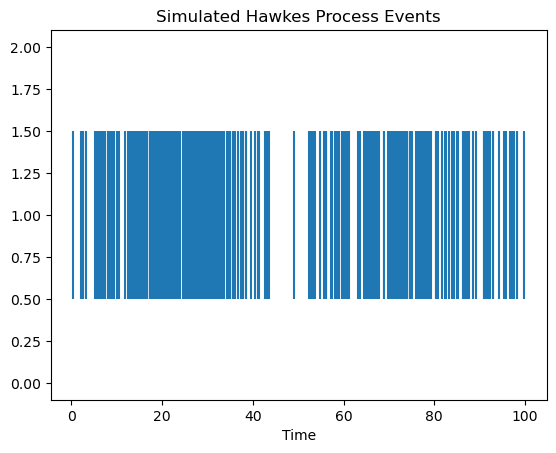

In [7]:
# Plot event timeline
plt.figure()
plt.eventplot(events, orientation="horizontal")
plt.title("Simulated Hawkes Process Events")
plt.xlabel("Time")
plt.show()

In [8]:
def hawkes_intensity(t, events, mu, alpha, beta):
    past_events = events[events < t]
    return mu + np.sum(alpha * np.exp(-beta * (t - past_events)))

We plot the hawkes intensity corresponding to our parameters to visualize more clearly the path of the process. 

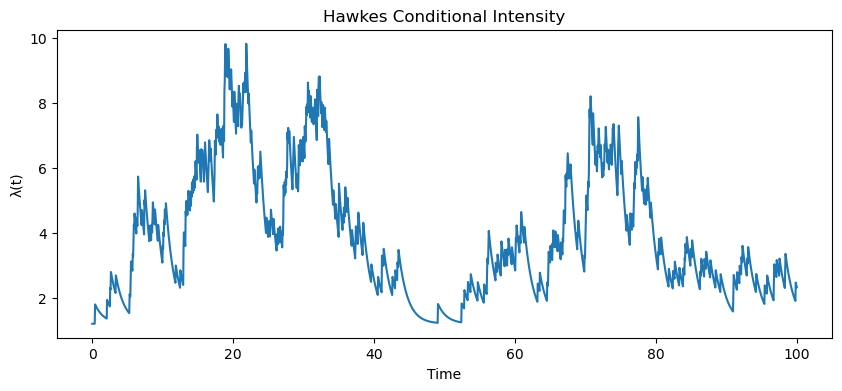

In [9]:
times = np.linspace(0, T, 2000)
intensity = [hawkes_intensity(t, events, mu, alpha, beta) for t in times]

plt.figure(figsize=(10,4))
plt.plot(times, intensity)
#plt.vlines(events, ymin=0, ymax=max(intensity), linestyles="dashed")
plt.xlabel("Time")
plt.ylabel("λ(t)")
plt.title("Hawkes Conditional Intensity")
plt.show()

## MLE estimator

For an Hawkes process we know that there exist a log-likelihood formula so a MLE estimator. Recall the general formula : 

$log(\mathcal{L}) = \sum_{i=1}^n log[\mu(t_i) + \sum_{k=1}^{i-1} \nu(t_i - t_k)] - \int _0 ^T[\mu(t) + \sum_{t_k < t} \nu(t - t_k)] dt$

As we use a 1 dimension exponential kernel, we're able to reduce this formula to : 

$\int _0 ^T\mu(t) dt + \frac{\alpha}{\beta} \sum _{i=1} ^n (1 - exp(-\beta (T - t_i)))$


In [ ]:
def hawkes_loglik(params, events, T):
    mu, alpha, beta = params
    
    if mu <= 0 or alpha <= 0 or beta <= 0:
        return np.inf
    
    n = len(events)
    
    intensity_sum = 0
    
    for i in range(n):
        ti = events[i]
        past = events[:i]
        
        excitation = np.sum(alpha * np.exp(-beta * (ti - past)))
        lam = mu + excitation
        
        intensity_sum += np.log(lam)
    
    compensator = mu*T + (alpha/beta)*np.sum(1 - np.exp(-beta*(T - events)))
    
    loglik = intensity_sum - compensator
    
    return -loglik

The well known major problem of the computation of this estimator is the complexity in O($n^2$)

In [11]:
def estimate_hawkes(events, T):

    init = np.array([0.1, 0.2, 1.0])

    bounds = [
        (1e-6, None),  # mu
        (1e-6, None),  # alpha
        (1e-6, None)   # beta
    ]

    result = minimize(
        hawkes_loglik,
        init,
        args=(events, T),
        bounds=bounds,
        method="L-BFGS-B"
    )

    return result.x

In [12]:
mu_hat, alpha_hat, beta_hat = estimate_hawkes(events, T)

In [13]:
print(mu_hat, alpha_hat, beta_hat)

0.6750796737948342 0.5311254529122718 0.6490187697961705


We see in the results above that without a lot of computation, we fail to compute the real parameters. 

In [14]:
def simulate_hawkes(mu, alpha, beta, T, seed=0):

    theta = 1 / beta
    eta = alpha / beta

    sim = ExpHawkesProcessSimulation(mu=mu, eta=eta, theta=theta)

    events = sim.simulate(T, seed=seed)

    return events

## Consistence of MLE estimator 

The above estimator, as we defined has three important properties that we will try to demonstrate empirically. 
First of all, it's a consistent estimator, which means that it converges in probability to the real values of the parameters. 

In [16]:
T_values = [50,100,200,400,800]

results = []

for T in T_values:

    events = simulate_hawkes(mu,alpha,beta,T)

    mu_hat,alpha_hat,beta_hat = estimate_hawkes(events,T)

    results.append([T,mu_hat,alpha_hat,beta_hat])

df = pd.DataFrame(
    results,
    columns=["T","mu_hat","alpha_hat","beta_hat"]
)

print(df)

     T    mu_hat  alpha_hat  beta_hat
0   50  0.947278   1.060316  1.427493
1  100  1.604711   0.468528  0.743470
2  200  1.145326   0.551523  0.729070
3  400  1.069345   0.597314  0.746467
4  800  1.191797   0.596619  0.802463


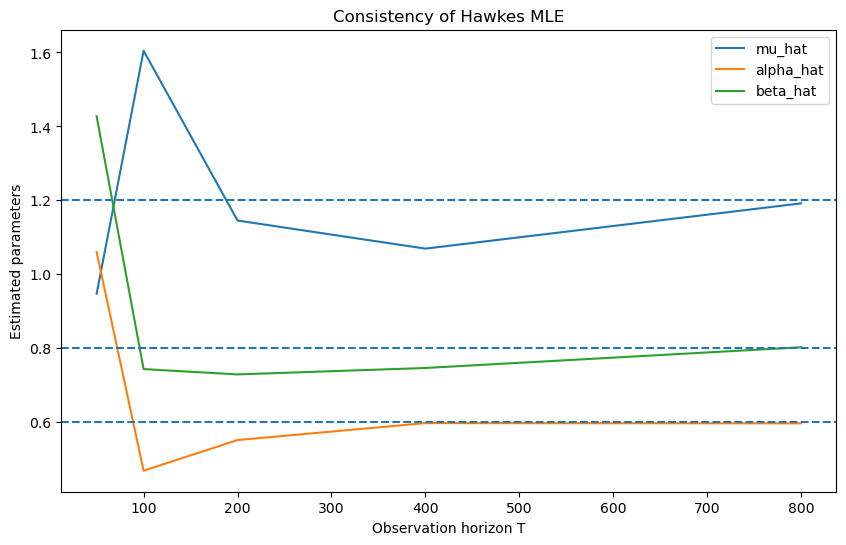

In [17]:
plt.figure(figsize=(10,6))

plt.plot(df["T"],df["mu_hat"],label="mu_hat")
plt.axhline(mu,linestyle="--")

plt.plot(df["T"],df["alpha_hat"],label="alpha_hat")
plt.axhline(alpha,linestyle="--")

plt.plot(df["T"],df["beta_hat"],label="beta_hat")
plt.axhline(beta,linestyle="--")

plt.xlabel("Observation horizon T")
plt.ylabel("Estimated parameters")

plt.legend()
plt.title("Consistency of Hawkes MLE")

plt.show()

We can observe in the above graph that as the time horizon get bigger, the estimation of the parameters computed with the defined MLE is reaching a good proxy for the real value. 

## Asymptotically normality of the Estimator

Now, we want to check the second property which is that the estimator of the distribution of the parameters tend to be normal as the number of simulation grows. 

Formally in mathematics : 

$\sqrt(T)(\hat{\theta} _T - \theta ^*) \rightarrow \mathcal{N}(0,I^{-1}(\theta ^*))$

In [32]:
theta_true = np.array([mu,alpha,beta])

T = 800
n_sim = 400

Z = []

for s in range(n_sim):

    events = simulate_hawkes(mu,alpha,beta,T,seed=s)

    theta_hat = estimate_hawkes(events,T)

    Z.append(np.sqrt(T)*(theta_hat-theta_true))

Z = np.array(Z)

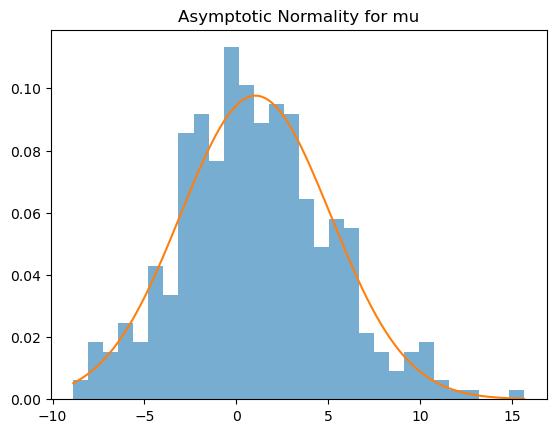

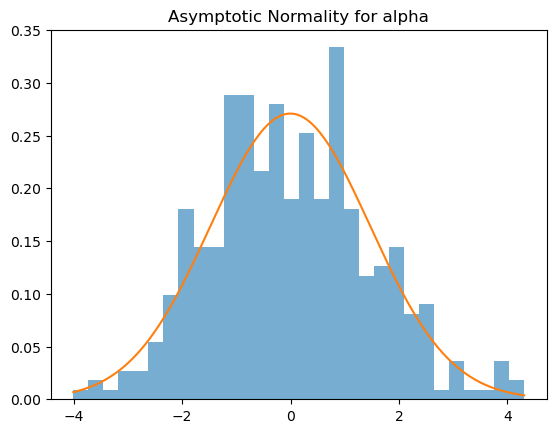

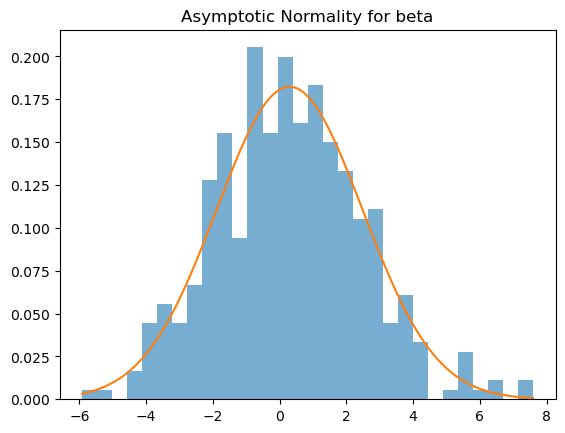

In [33]:
params = ["mu","alpha","beta"]

for i in range(3):

    plt.figure()

    plt.hist(Z[:,i], bins=30, density=True, alpha=0.6)

    x = np.linspace(min(Z[:,i]),max(Z[:,i]),200)

    plt.plot(x, stats.norm.pdf(x,np.mean(Z[:,i]),np.std(Z[:,i])))

    plt.title(f"Asymptotic Normality for {params[i]}")
    
    plt.show()

The above histograms show that the distribution of the value of the estimated parameters tend to fit a Gaussian Law. 

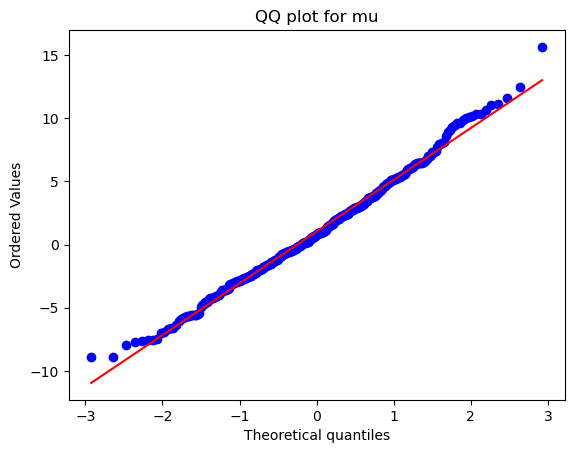

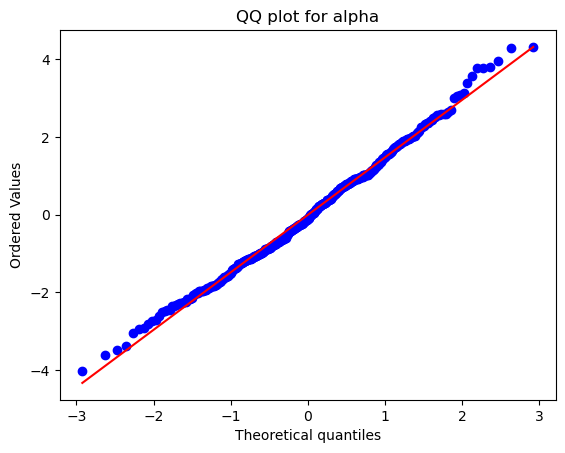

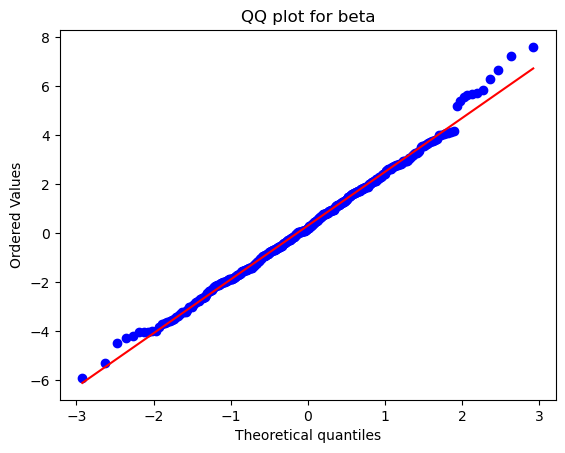

In [34]:
for i in range(3):

    stats.probplot(Z[:,i], dist="norm", plot=plt)

    plt.title(f"QQ plot for {params[i]}")
    
    plt.show()

The QQ-plot for the estimated parameters tend to confirm our first visualisation and prove the second property of the MLE estimator. 

## Asymptotically Efficience

In this third part we want to show that the estimator is asymptotically efficient which means that the estimator reaches the lower bound of the variance of an estimate. 

We try here to use a notion presented in the following document known as the Cramer-Rao bound. 

https://perso.telecom-paristech.fr/ciblat/docs_cours/freq_crb.pdf

For an estimator, if it succeed to reach the Cramer-Rao boud, we say that it's an efficient estimator. 

We are now in the position to define the numerical hessian function, which will help us lately approximating the Fisher Information matrix of the Log-Likelihood estimator. Formally it gives an estimate of $I(\theta ^*)$

In [ ]:
def numerical_hessian(f, x, eps=1e-4, *args):

    n = len(x)
    H = np.zeros((n,n))

    for i in range(n):
        for j in range(n):

            x1 = x.copy(); x1[i]+=eps; x1[j]+=eps
            x2 = x.copy(); x2[i]+=eps; x2[j]-=eps
            x3 = x.copy(); x3[i]-=eps; x3[j]+=eps
            x4 = x.copy(); x4[i]-=eps; x4[j]-=eps

            H[i,j] = (
                f(x1,*args) - f(x2,*args)
                - f(x3,*args) + f(x4,*args)
            )/(4*eps**2)

    return H

We then define $\theta$ which is our vector of true parameters

In [22]:
theta_true = np.array([mu,alpha,beta])

We then simulate over a quite long time horizon our Hawkes process to be able to extract values of the parameters. 

In [37]:
T = 800
n_sim = 200

theta_hat_list = []

for s in range(n_sim):

    events = simulate_hawkes(mu,alpha,beta,T,seed=s)

    theta_hat = estimate_hawkes(events,T)

    theta_hat_list.append(theta_hat)

theta_hat_list = np.array(theta_hat_list)

We compute the covariance matrix of the parameters we obtained by simulation.

In [38]:
emp_cov = np.cov(theta_hat_list.T)

print("Empirical covariance:")
print(emp_cov)

Empirical covariance:
[[0.02075253 0.00028232 0.0051733 ]
 [0.00028232 0.00259256 0.00331137]
 [0.0051733  0.00331137 0.00564815]]


Then, we compute the Cramer-Rao bound for this simulations using the following relationhips : 

Cramer-Rao Bound $= \frac{1}{T} I^{-1}(\theta ^*)$

In [27]:
events = simulate_hawkes(mu,alpha,beta,T,seed=999)

H = numerical_hessian(hawkes_loglik,theta_true,1e-4,events,T)

fisher_info = H / T

cramer_rao = inv(fisher_info)

print("Cramer-Rao bound:")
print(cramer_rao)

Cramer-Rao bound:
[[20.11330892  1.01768576  5.49785639]
 [ 1.01768576  2.18568193  3.02974951]
 [ 5.49785639  3.02974951  5.27083681]]


Then, we compare, following the relationships defined above, $T \times Cov(\hat{\theta}_T)$ and the Cramer-Rao Bound

In [29]:
print("Empirical covariance * T:")
print(emp_cov*T)

print("Inverse Fisher information:")
print(cramer_rao)

Empirical covariance * T:


NameError: name 'emp_cov' is not defined

We see that we are quite far, then we need to simulate over different time horizon with quite a large number of simulations. As we know that the estimator has complexity O($n^2$). This step will take a lot of time

In [ ]:
#This cell takes 300 minutes to compute
T_values = [200,500,1000,2000,4000]
n_sim = 300

var_mu = []
var_alpha = []
var_beta = []

for T in T_values:
    print(T)

    estimates = [] 

    for s in range(n_sim):

        events = simulate_hawkes(mu,alpha,beta,T,seed=s)

        theta_hat = estimate_hawkes(events,T)

        estimates.append(theta_hat)

    estimates = np.array(estimates)

    cov = np.cov(estimates.T)

    var_mu.append(T*cov[0,0])
    var_alpha.append(T*cov[1,1])
    var_beta.append(T*cov[2,2])

200
500
1000
2000
4000


In [26]:
events = simulate_hawkes(mu,alpha,beta,4000,seed=999)

H = numerical_hessian(hawkes_loglik,theta_true,1e-4,events,4000)

fisher_info = H / T

cramer_rao = inv(fisher_info)

print("Cramer-Rao bound:")
print(cramer_rao)

Cramer-Rao bound:
[[20.11330892  1.01768576  5.49785639]
 [ 1.01768576  2.18568193  3.02974951]
 [ 5.49785639  3.02974951  5.27083681]]


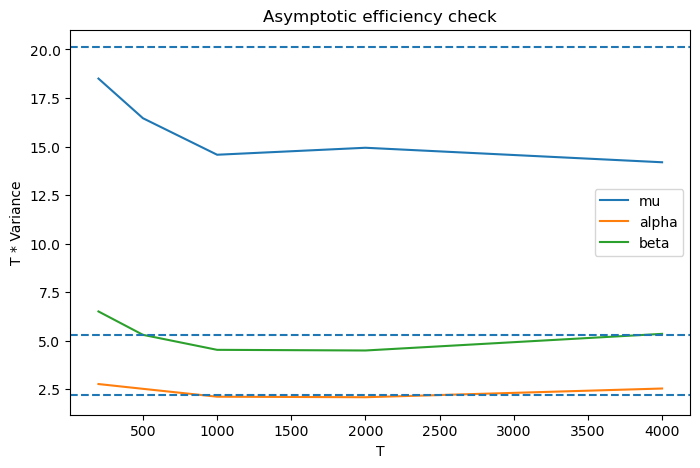

In [28]:
plt.figure(figsize=(8,5))

plt.plot(T_values,var_mu,label="mu")
plt.plot(T_values,var_alpha,label="alpha")
plt.plot(T_values,var_beta,label="beta")

plt.axhline(cramer_rao[0,0],linestyle="--")
plt.axhline(cramer_rao[1,1],linestyle="--")
plt.axhline(cramer_rao[2,2],linestyle="--")

plt.xlabel("T")
plt.ylabel("T * Variance")
plt.title("Asymptotic efficiency check")

plt.legend()
plt.show()

Finally we are able to plot the evolution of the value of our estimator compared to the boundaries. It appear that for $\alpha$ and $\beta$ the code provided is able to reach the Cramer-Rao bound. Otherwise for $\mu$, we are quite far. 

As we didn't have a lot of time to improve du to the lenght of the simulation we chose to let it like that. 

# Computational cost of Hawkes simulators

In this section we will test two algorithm that were presented in class to simulate Hawkes process and for each algorithm we will test 5 types of kernel to assess performances. 

## Thining Algorithm

A thinning algorithm is a method used to randomly remove points from a point process or dataset while preserving a desired statistical property or target distribution by accepting each point with a probability chosen so that the remaining points follow a specified intensity function.

In [72]:
def hawkes_thinning(T, mu, nu, lambda_t, nu_0):
    """
    Simulate a 1D Hawkes process using the thinning algorithm.

    Parameters:
        T         : float - simulation horizon
        mu        : callable - baseline intensity mu(t)
        nu        : callable - kernel function nu(t)
        lambda_t  : callable - conditional intensity lambda(t, events)
        nu_0      : float - nu(0), the jump size at 0

    Returns:
        events : list of event times
    """
    t = 0.0
    lambda_star = mu(0)
    events = []

    while t < T:
        U = np.random.exponential(1.0 / lambda_star)
        t = t + U

        if t >= T:
            return events

        lam = lambda_t(t, events)
        D = np.random.uniform(0, 1)

        if D <= lam / lambda_star:
            events.append(t)
            lambda_star = lam + nu_0
        else:
            lambda_star = lam

    return events

### Exponential Kernel

In [73]:
%%time

T      = 100.0   
mu0    = 0.5     
alpha  = 0.8     
beta   = 1.0     

def mu(t):
    return mu0

def nu(s):
    return alpha * np.exp(-beta * s)

nu_0 = nu(0)   

def lambda_t(t, events):
    return mu(t) + sum(nu(t - s) for s in events if s < t)

np.random.seed(42)
events = hawkes_thinning(T, mu, nu, lambda_t, nu_0)

print(f"Number of events : {len(events)}")
print(f"First 10 events  : {[round(e, 4) for e in events[:10]]}")
print(f"Empirical rate   : {len(events) / T:.4f}  "
        f"(theoretical: {mu0 / (1 - alpha/beta):.4f})")

Number of events : 204
First 10 events  : [0.9385, 1.9514, 2.0581, 2.0843, 2.3872, 2.3938, 2.8455, 2.9029, 2.9907, 3.1129]
Empirical rate   : 2.0400  (theoretical: 2.5000)
CPU times: user 18.8 ms, sys: 2.03 ms, total: 20.8 ms
Wall time: 21.5 ms


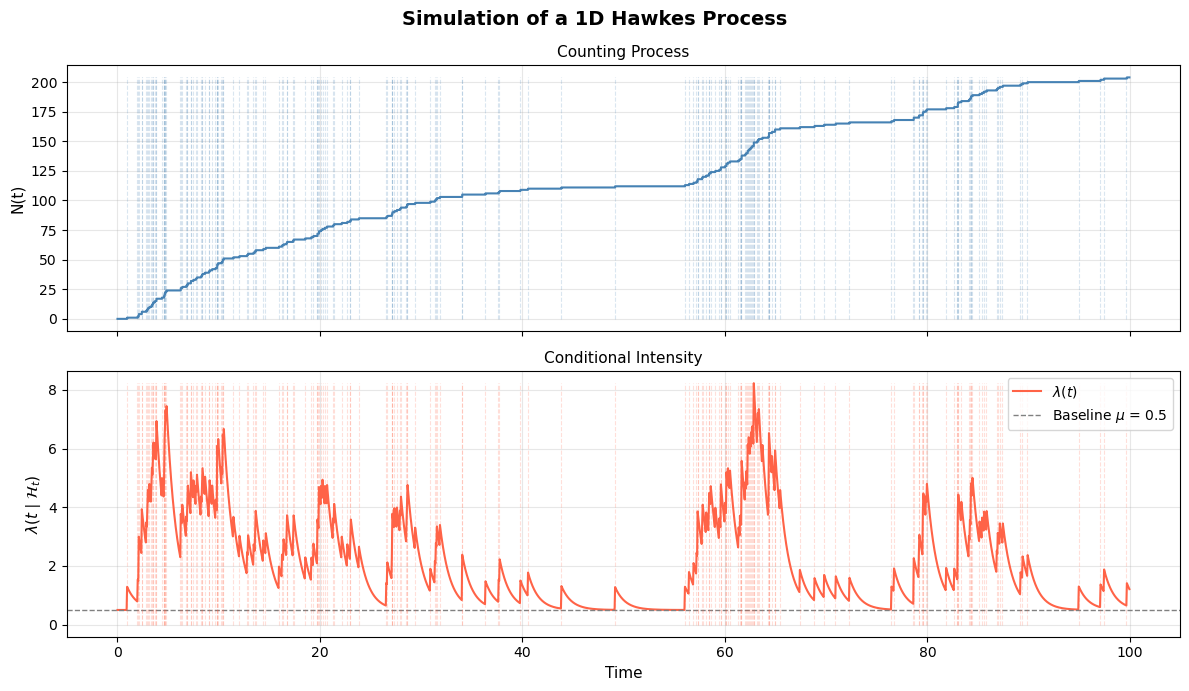

In [74]:
time_grid = np.arange(0, T, 0.05)

counting  = np.searchsorted(events, time_grid, side='right')
intensity = np.array([lambda_t(t, events) for t in time_grid])

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle("Simulation of a 1D Hawkes Process", fontsize=14, fontweight='bold')

axes[0].step(time_grid, counting, where='post', color='steelblue', linewidth=1.5)
axes[0].vlines(events, 0, counting.max(), color='steelblue', alpha=0.2, linewidth=0.8, linestyle='--')
axes[0].set_ylabel("N(t)", fontsize=11)
axes[0].set_title("Counting Process", fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_grid, intensity, color='tomato', linewidth=1.5, label=r'$\lambda(t)$')
axes[1].axhline(mu(0), color='gray', linestyle='--', linewidth=1, label=rf'Baseline $\mu$ = {mu(0)}')
axes[1].vlines(events, 0, intensity.max(), color='tomato', alpha=0.2, linewidth=0.8, linestyle='--')
axes[1].set_xlabel("Time", fontsize=11)
axes[1].set_ylabel(r"$\lambda(t \mid \mathcal{H}_t)$", fontsize=11)
axes[1].set_title("Conditional Intensity", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Power-Law Kernel

In [75]:
%%time

T      = 10.0   
mu0    = 0.5     
alpha  = 0.8     
beta   = 1.0  
c = 0.33
p = 1.2

def mu(t):
    return mu0

def nu(s):
    return alpha * (s + c) ** (-p)

nu_0 = nu(0)   

def lambda_t(t, events):
    return mu(t) + sum(nu(t - s) for s in events if s < t)

np.random.seed(42)
events = hawkes_thinning(T, mu, nu, lambda_t, nu_0)

print(f"Number of events : {len(events)}")

Number of events : 81998
CPU times: user 3min 38s, sys: 781 ms, total: 3min 39s
Wall time: 3min 39s


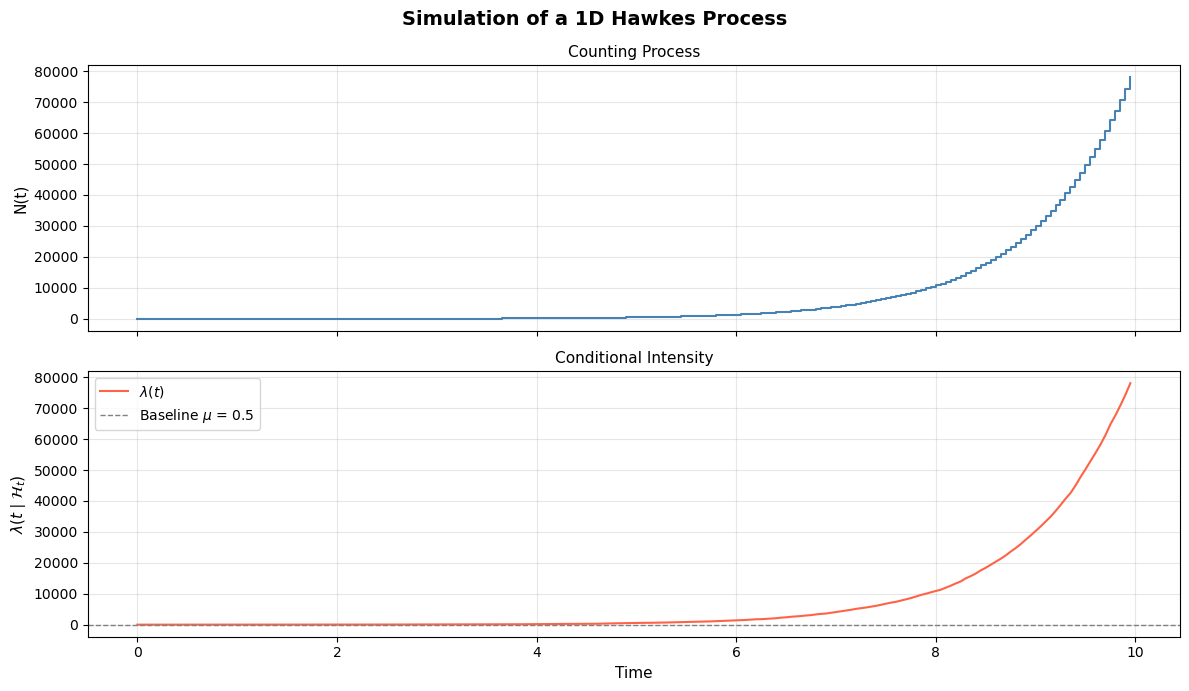

In [76]:
time_grid = np.arange(0, T, 0.05)

counting  = np.searchsorted(events, time_grid, side='right')
intensity = np.array([lambda_t(t, events) for t in time_grid])

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle("Simulation of a 1D Hawkes Process", fontsize=14, fontweight='bold')

axes[0].step(time_grid, counting, where='post', color='steelblue', linewidth=1.5)
#axes[0].vlines(events, 0, counting.max(), color='steelblue', alpha=0.2, linewidth=0.8, linestyle='--')
axes[0].set_ylabel("N(t)", fontsize=11)
axes[0].set_title("Counting Process", fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_grid, intensity, color='tomato', linewidth=1.5, label=r'$\lambda(t)$')
axes[1].axhline(mu(0), color='gray', linestyle='--', linewidth=1, label=rf'Baseline $\mu$ = {mu(0)}')
#axes[1].vlines(events, 0, intensity.max(), color='tomato', alpha=0.2, linewidth=0.8, linestyle='--')
axes[1].set_xlabel("Time", fontsize=11)
axes[1].set_ylabel(r"$\lambda(t \mid \mathcal{H}_t)$", fontsize=11)
axes[1].set_title("Conditional Intensity", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Rayleigh Kernel

In [77]:
%%time

T      = 100.0   
mu0    = 0.5     
alpha  = 0.8     
beta   = 1.0  

def mu(t):
    return mu0

def nu(s):
    return alpha * s * np.exp(-beta * s**2 / 2)

nu_0 = nu(0)   

def lambda_t(t, events):
    return mu(t) + sum(nu(t - s) for s in events if s < t)

np.random.seed(42)
events = hawkes_thinning(T, mu, nu, lambda_t, nu_0)

print(f"Number of events : {len(events)}")

Number of events : 132
CPU times: user 5.31 ms, sys: 452 μs, total: 5.76 ms
Wall time: 6.32 ms


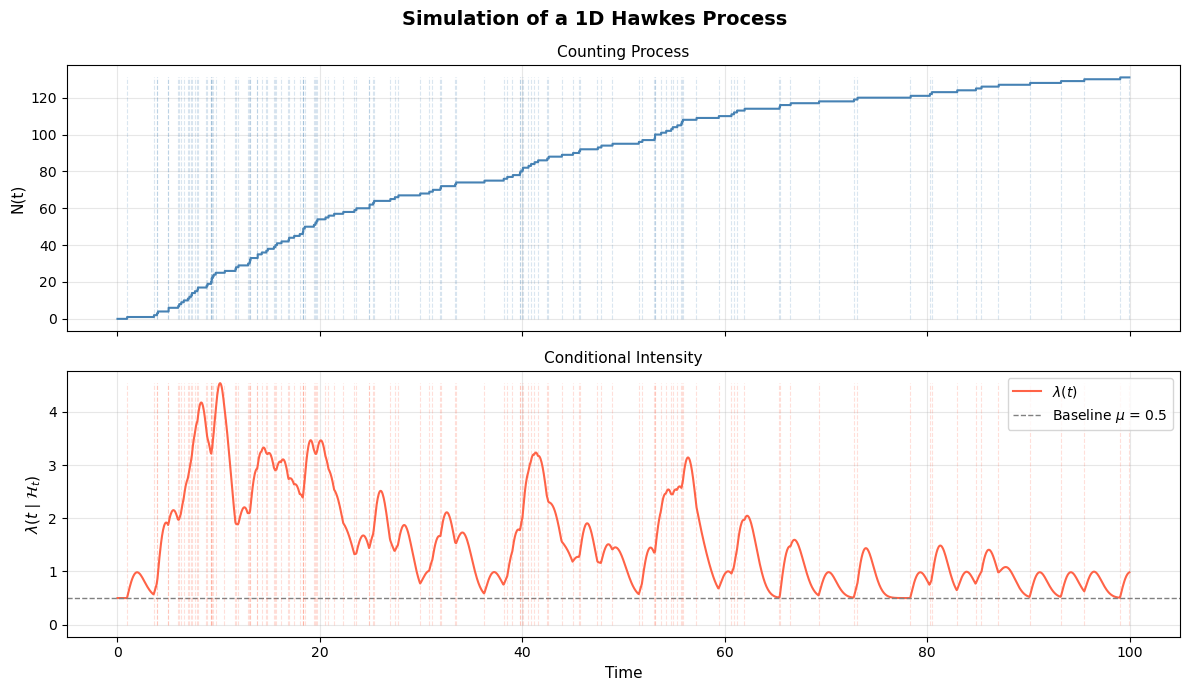

In [78]:
time_grid = np.arange(0, T, 0.05)

counting  = np.searchsorted(events, time_grid, side='right')
intensity = np.array([lambda_t(t, events) for t in time_grid])

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle("Simulation of a 1D Hawkes Process", fontsize=14, fontweight='bold')

axes[0].step(time_grid, counting, where='post', color='steelblue', linewidth=1.5)
axes[0].vlines(events, 0, counting.max(), color='steelblue', alpha=0.2, linewidth=0.8, linestyle='--')
axes[0].set_ylabel("N(t)", fontsize=11)
axes[0].set_title("Counting Process", fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_grid, intensity, color='tomato', linewidth=1.5, label=r'$\lambda(t)$')
axes[1].axhline(mu(0), color='gray', linestyle='--', linewidth=1, label=rf'Baseline $\mu$ = {mu(0)}')
axes[1].vlines(events, 0, intensity.max(), color='tomato', alpha=0.2, linewidth=0.8, linestyle='--')
axes[1].set_xlabel("Time", fontsize=11)
axes[1].set_ylabel(r"$\lambda(t \mid \mathcal{H}_t)$", fontsize=11)
axes[1].set_title("Conditional Intensity", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Gaussian bump

In [79]:
%%time

T      = 100.0   
mu0    = 0.5     
alpha  = 0.8     
beta   = 1.0  
mu_k = 0.33
sigma = 0.25

def mu(t):
    return mu0

def nu(s):
    return alpha * np.exp(-(s - mu_k)**2 / (2 * sigma**2))

nu_0 = nu(0)   

def lambda_t(t, events):
    return mu(t) + sum(nu(t - s) for s in events if s < t)

np.random.seed(42)
events = hawkes_thinning(T, mu, nu, lambda_t, nu_0)

print(f"Number of events : {len(events)}")

Number of events : 93
CPU times: user 2.8 ms, sys: 178 μs, total: 2.97 ms
Wall time: 2.87 ms


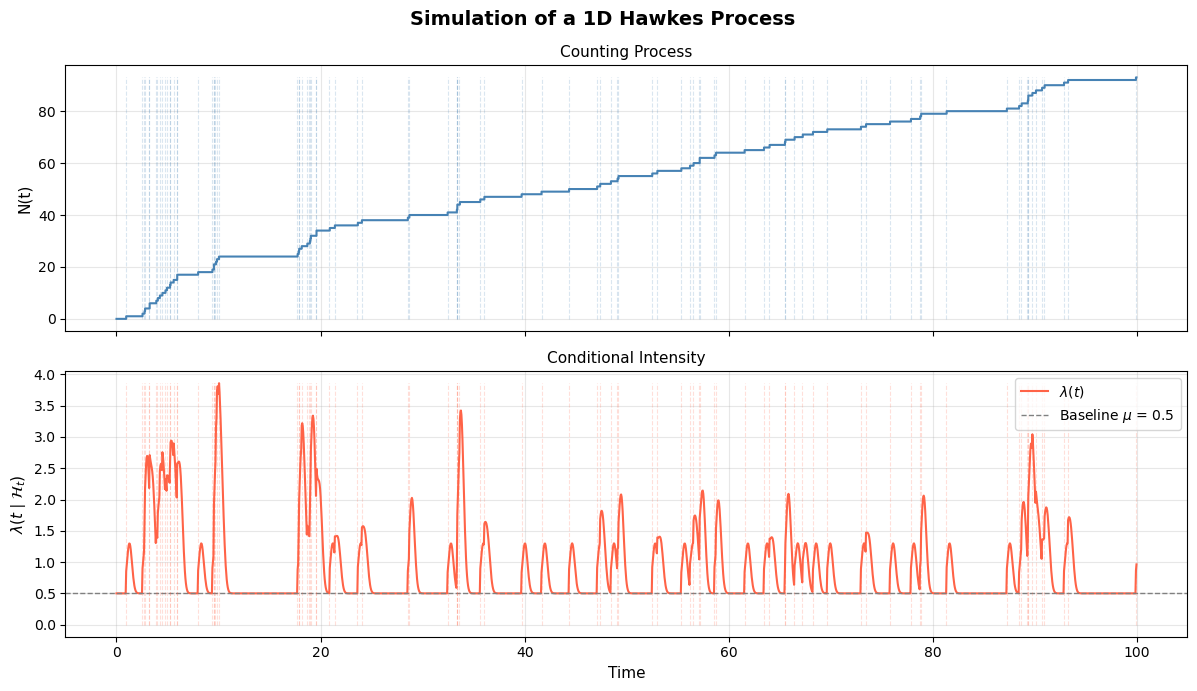

In [80]:
time_grid = np.arange(0, T, 0.05)

counting  = np.searchsorted(events, time_grid, side='right')
intensity = np.array([lambda_t(t, events) for t in time_grid])

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle("Simulation of a 1D Hawkes Process", fontsize=14, fontweight='bold')

axes[0].step(time_grid, counting, where='post', color='steelblue', linewidth=1.5)
axes[0].vlines(events, 0, counting.max(), color='steelblue', alpha=0.2, linewidth=0.8, linestyle='--')
axes[0].set_ylabel("N(t)", fontsize=11)
axes[0].set_title("Counting Process", fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_grid, intensity, color='tomato', linewidth=1.5, label=r'$\lambda(t)$')
axes[1].axhline(mu(0), color='gray', linestyle='--', linewidth=1, label=rf'Baseline $\mu$ = {mu(0)}')
axes[1].vlines(events, 0, intensity.max(), color='tomato', alpha=0.2, linewidth=0.8, linestyle='--')
axes[1].set_xlabel("Time", fontsize=11)
axes[1].set_ylabel(r"$\lambda(t \mid \mathcal{H}_t)$", fontsize=11)
axes[1].set_title("Conditional Intensity", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Pareto Kernel

In [81]:
%%time

T      = 100.0   
mu0    = 0.5     
alpha  = 0.8     
beta   = 1.0  
p = 1.25

def mu(t):
    return mu0

def nu(s):
    return alpha * (beta / (s + beta)) ** (p + 1)

nu_0 = nu(0)   

def lambda_t(t, events):
    return mu(t) + sum(nu(t - s) for s in events if s < t)

np.random.seed(42)
events = hawkes_thinning(T, mu, nu, lambda_t, nu_0)

print(f"Number of events : {len(events)}")

Number of events : 148
CPU times: user 1.43 ms, sys: 3 μs, total: 1.43 ms
Wall time: 1.43 ms


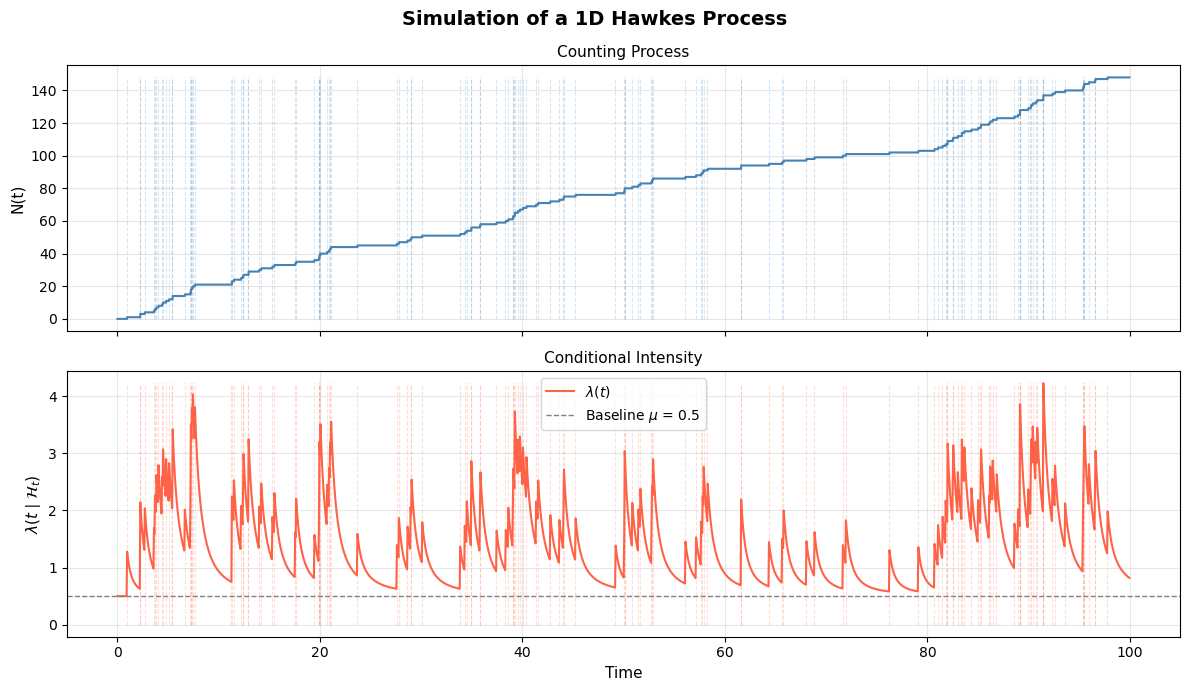

In [82]:
time_grid = np.arange(0, T, 0.05)

counting  = np.searchsorted(events, time_grid, side='right')
intensity = np.array([lambda_t(t, events) for t in time_grid])

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle("Simulation of a 1D Hawkes Process", fontsize=14, fontweight='bold')

axes[0].step(time_grid, counting, where='post', color='steelblue', linewidth=1.5)
axes[0].vlines(events, 0, counting.max(), color='steelblue', alpha=0.2, linewidth=0.8, linestyle='--')
axes[0].set_ylabel("N(t)", fontsize=11)
axes[0].set_title("Counting Process", fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_grid, intensity, color='tomato', linewidth=1.5, label=r'$\lambda(t)$')
axes[1].axhline(mu(0), color='gray', linestyle='--', linewidth=1, label=rf'Baseline $\mu$ = {mu(0)}')
axes[1].vlines(events, 0, intensity.max(), color='tomato', alpha=0.2, linewidth=0.8, linestyle='--')
axes[1].set_xlabel("Time", fontsize=11)
axes[1].set_ylabel(r"$\lambda(t \mid \mathcal{H}_t)$", fontsize=11)
axes[1].set_title("Conditional Intensity", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Branching Algorithm

In [83]:
%%timeit

T     = 100.0
mu0   = 0.5   
alpha = 0.6    
beta  = 1.0  

immigrants = sorted(np.random.uniform(0, T, np.random.poisson(mu0 * T)))

all_events  = [(t, 0) for t in immigrants]  
current_gen = immigrants

gen = 0
while len(current_gen) > 0:
    gen += 1
    next_gen = []
    for parent in current_gen:
        n_offspring = np.random.poisson(alpha)
        for _ in range(n_offspring):
            delay = np.random.exponential(1.0 / beta)
            child = parent + delay
            if child < T:
                next_gen.append(child)
                all_events.append((child, gen))
    current_gen = next_gen

all_events.sort(key=lambda x: x[0])
times       = np.array([e[0] for e in all_events])
generations = np.array([e[1] for e in all_events])
n_gen       = generations.max() + 1

84.8 μs ± 808 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### Exponential Kernel

In [84]:
%%time

def nu(s):
    return alpha * np.exp(-beta * s)

def lambda_t(t):
    return mu0 + sum(nu(t - s) for s in times if s < t)

time_grid = np.arange(0, T, 0.05)
intensity = np.array([lambda_t(t) for t in time_grid])
counting  = np.searchsorted(times, time_grid, side='right')

CPU times: user 58.8 ms, sys: 943 μs, total: 59.8 ms
Wall time: 59.4 ms


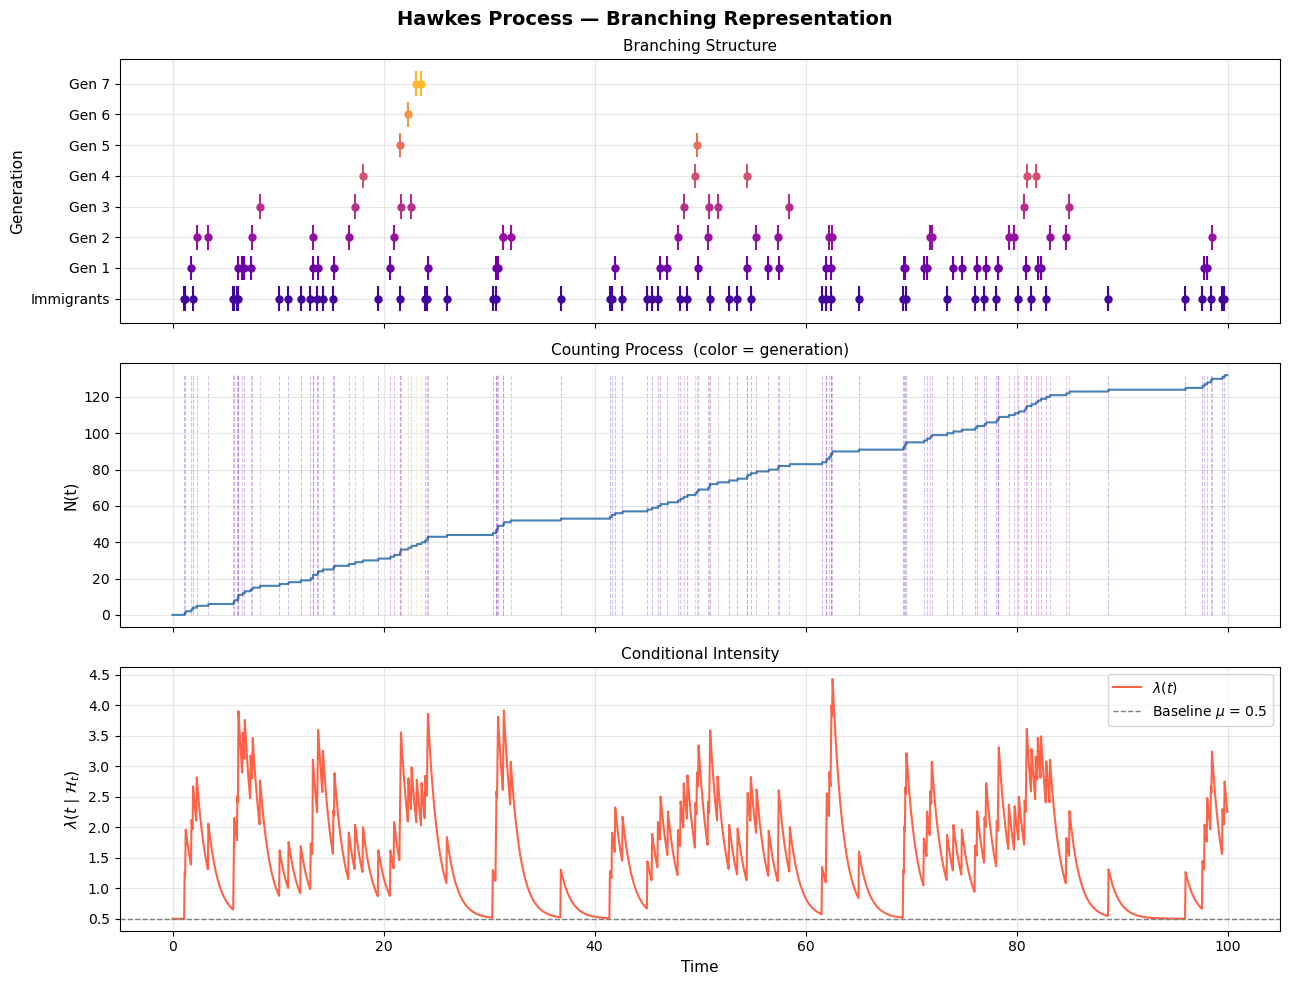

In [85]:
colors = plt.cm.plasma(np.linspace(0.1, 0.85, n_gen))

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
fig.suptitle("Hawkes Process — Branching Representation", fontsize=14, fontweight='bold')

# --- Panel 1: branching structure ---
ax = axes[0]
for t, g in all_events:
    ax.vlines(t, g - 0.4, g + 0.4, color=colors[g], linewidth=1.5)
    ax.scatter(t, g, color=colors[g], s=25, zorder=3)
ax.set_yticks(range(n_gen))
ax.set_yticklabels([f"Gen {i}" if i > 0 else "Immigrants" for i in range(n_gen)])
ax.set_ylabel("Generation", fontsize=11)
ax.set_title("Branching Structure", fontsize=11)
ax.grid(True, alpha=0.3)

# --- Panel 2: counting process ---
ax = axes[1]
ax.step(time_grid, counting, where='post', color='steelblue', linewidth=1.5)
for t, g in all_events:
    ax.vlines(t, 0, counting.max(), color=colors[g], alpha=0.25, linewidth=0.8, linestyle='--')
ax.set_ylabel("N(t)", fontsize=11)
ax.set_title("Counting Process  (color = generation)", fontsize=11)
ax.grid(True, alpha=0.3)

# --- Panel 3: conditional intensity ---
ax = axes[2]
ax.plot(time_grid, intensity, color='tomato', linewidth=1.5, label=r'$\lambda(t)$')
ax.axhline(mu0, color='gray', linestyle='--', linewidth=1, label=rf'Baseline $\mu$ = {mu0}')
ax.set_xlabel("Time", fontsize=11)
ax.set_ylabel(r"$\lambda(t \mid \mathcal{H}_t)$", fontsize=11)
ax.set_title("Conditional Intensity", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Power-Law Kernel

In [86]:
%%time

T     = 100.0
mu0   = 0.5   
alpha = 0.6    
beta  = 1.0  

immigrants = sorted(np.random.uniform(0, T, np.random.poisson(mu0 * T)))

all_events  = [(t, 0) for t in immigrants]  
current_gen = immigrants

gen = 0
while len(current_gen) > 0:
    gen += 1
    next_gen = []
    for parent in current_gen:
        n_offspring = np.random.poisson(alpha)
        for _ in range(n_offspring):
            delay = np.random.exponential(1.0 / beta)
            child = parent + delay
            if child < T:
                next_gen.append(child)
                all_events.append((child, gen))
    current_gen = next_gen

all_events.sort(key=lambda x: x[0])
times       = np.array([e[0] for e in all_events])
generations = np.array([e[1] for e in all_events])
n_gen       = generations.max() + 1

CPU times: user 208 μs, sys: 33 μs, total: 241 μs
Wall time: 299 μs


In [87]:
%%time

c = 0.33
p = 1.2

def nu(s):
    return alpha * (s + c) ** (-p)

def lambda_t(t):
    return mu0 + sum(nu(t - s) for s in times if s < t)

time_grid = np.arange(0, T, 0.05)
intensity = np.array([lambda_t(t) for t in time_grid])
counting  = np.searchsorted(times, time_grid, side='right')

CPU times: user 28 ms, sys: 1.14 ms, total: 29.2 ms
Wall time: 29 ms


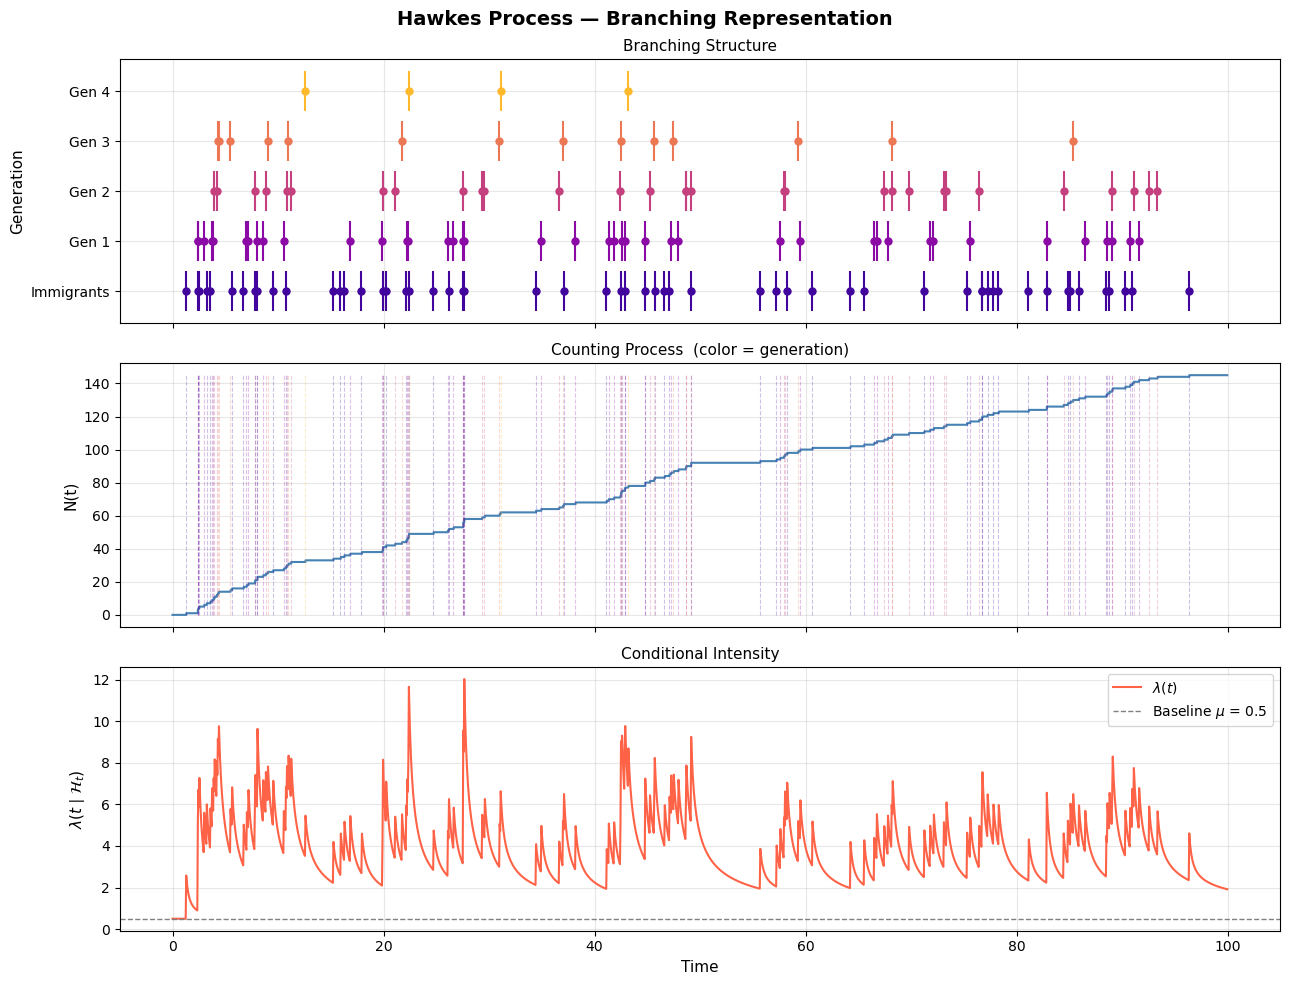

In [88]:
colors = plt.cm.plasma(np.linspace(0.1, 0.85, n_gen))

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
fig.suptitle("Hawkes Process — Branching Representation", fontsize=14, fontweight='bold')

ax = axes[0]
for t, g in all_events:
    ax.vlines(t, g - 0.4, g + 0.4, color=colors[g], linewidth=1.5)
    ax.scatter(t, g, color=colors[g], s=25, zorder=3)
ax.set_yticks(range(n_gen))
ax.set_yticklabels([f"Gen {i}" if i > 0 else "Immigrants" for i in range(n_gen)])
ax.set_ylabel("Generation", fontsize=11)
ax.set_title("Branching Structure", fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.step(time_grid, counting, where='post', color='steelblue', linewidth=1.5)
for t, g in all_events:
    ax.vlines(t, 0, counting.max(), color=colors[g], alpha=0.25, linewidth=0.8, linestyle='--')
ax.set_ylabel("N(t)", fontsize=11)
ax.set_title("Counting Process  (color = generation)", fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(time_grid, intensity, color='tomato', linewidth=1.5, label=r'$\lambda(t)$')
ax.axhline(mu0, color='gray', linestyle='--', linewidth=1, label=rf'Baseline $\mu$ = {mu0}')
ax.set_xlabel("Time", fontsize=11)
ax.set_ylabel(r"$\lambda(t \mid \mathcal{H}_t)$", fontsize=11)
ax.set_title("Conditional Intensity", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Rayleigh Kernel

In [89]:
%%time

T     = 100.0
mu0   = 0.5   
alpha = 0.6    
beta  = 1.0  

immigrants = sorted(np.random.uniform(0, T, np.random.poisson(mu0 * T)))

all_events  = [(t, 0) for t in immigrants]  
current_gen = immigrants

gen = 0
while len(current_gen) > 0:
    gen += 1
    next_gen = []
    for parent in current_gen:
        n_offspring = np.random.poisson(alpha)
        for _ in range(n_offspring):
            delay = np.random.exponential(1.0 / beta)
            child = parent + delay
            if child < T:
                next_gen.append(child)
                all_events.append((child, gen))
    current_gen = next_gen

all_events.sort(key=lambda x: x[0])
times       = np.array([e[0] for e in all_events])
generations = np.array([e[1] for e in all_events])
n_gen       = generations.max() + 1

CPU times: user 132 μs, sys: 4 μs, total: 136 μs
Wall time: 134 μs


In [90]:
%%time

def nu(s):
    return alpha * s * np.exp(-beta * s**2 / 2)

def lambda_t(t):
    return mu0 + sum(nu(t - s) for s in times if s < t)

time_grid = np.arange(0, T, 0.05)
intensity = np.array([lambda_t(t) for t in time_grid])
counting  = np.searchsorted(times, time_grid, side='right')

CPU times: user 57 ms, sys: 1.14 ms, total: 58.2 ms
Wall time: 57.9 ms


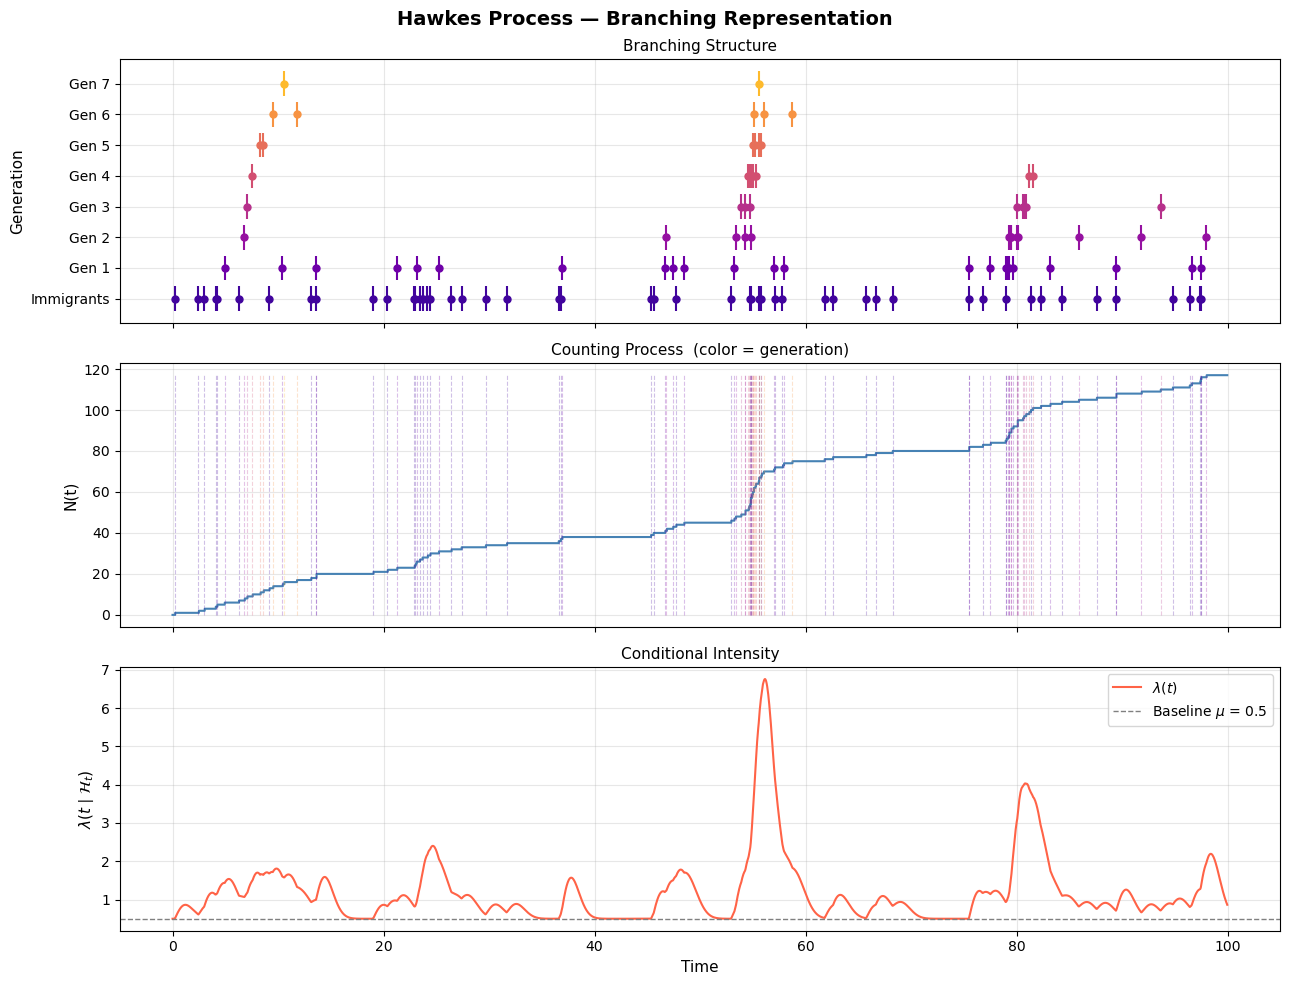

In [91]:
colors = plt.cm.plasma(np.linspace(0.1, 0.85, n_gen))

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
fig.suptitle("Hawkes Process — Branching Representation", fontsize=14, fontweight='bold')

ax = axes[0]
for t, g in all_events:
    ax.vlines(t, g - 0.4, g + 0.4, color=colors[g], linewidth=1.5)
    ax.scatter(t, g, color=colors[g], s=25, zorder=3)
ax.set_yticks(range(n_gen))
ax.set_yticklabels([f"Gen {i}" if i > 0 else "Immigrants" for i in range(n_gen)])
ax.set_ylabel("Generation", fontsize=11)
ax.set_title("Branching Structure", fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.step(time_grid, counting, where='post', color='steelblue', linewidth=1.5)
for t, g in all_events:
    ax.vlines(t, 0, counting.max(), color=colors[g], alpha=0.25, linewidth=0.8, linestyle='--')
ax.set_ylabel("N(t)", fontsize=11)
ax.set_title("Counting Process  (color = generation)", fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(time_grid, intensity, color='tomato', linewidth=1.5, label=r'$\lambda(t)$')
ax.axhline(mu0, color='gray', linestyle='--', linewidth=1, label=rf'Baseline $\mu$ = {mu0}')
ax.set_xlabel("Time", fontsize=11)
ax.set_ylabel(r"$\lambda(t \mid \mathcal{H}_t)$", fontsize=11)
ax.set_title("Conditional Intensity", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Gaussian Bump

In [92]:
%%time

T     = 100.0
mu0   = 0.5   
alpha = 0.6    
beta  = 1.0  

immigrants = sorted(np.random.uniform(0, T, np.random.poisson(mu0 * T)))

all_events  = [(t, 0) for t in immigrants]  
current_gen = immigrants

gen = 0
while len(current_gen) > 0:
    gen += 1
    next_gen = []
    for parent in current_gen:
        n_offspring = np.random.poisson(alpha)
        for _ in range(n_offspring):
            delay = np.random.exponential(1.0 / beta)
            child = parent + delay
            if child < T:
                next_gen.append(child)
                all_events.append((child, gen))
    current_gen = next_gen

all_events.sort(key=lambda x: x[0])
times       = np.array([e[0] for e in all_events])
generations = np.array([e[1] for e in all_events])
n_gen       = generations.max() + 1

CPU times: user 165 μs, sys: 4 μs, total: 169 μs
Wall time: 166 μs


In [ ]:
%%time

def nu(s):
    return alpha * np.exp(-(s - mu_k)**2 / (2 * sigma**2))

def lambda_t(t):
    return mu0 + sum(nu(t - s) for s in times if s < t)

time_grid = np.arange(0, T, 0.05)
intensity = np.array([lambda_t(t) for t in time_grid])
counting  = np.searchsorted(times, time_grid, side='right')

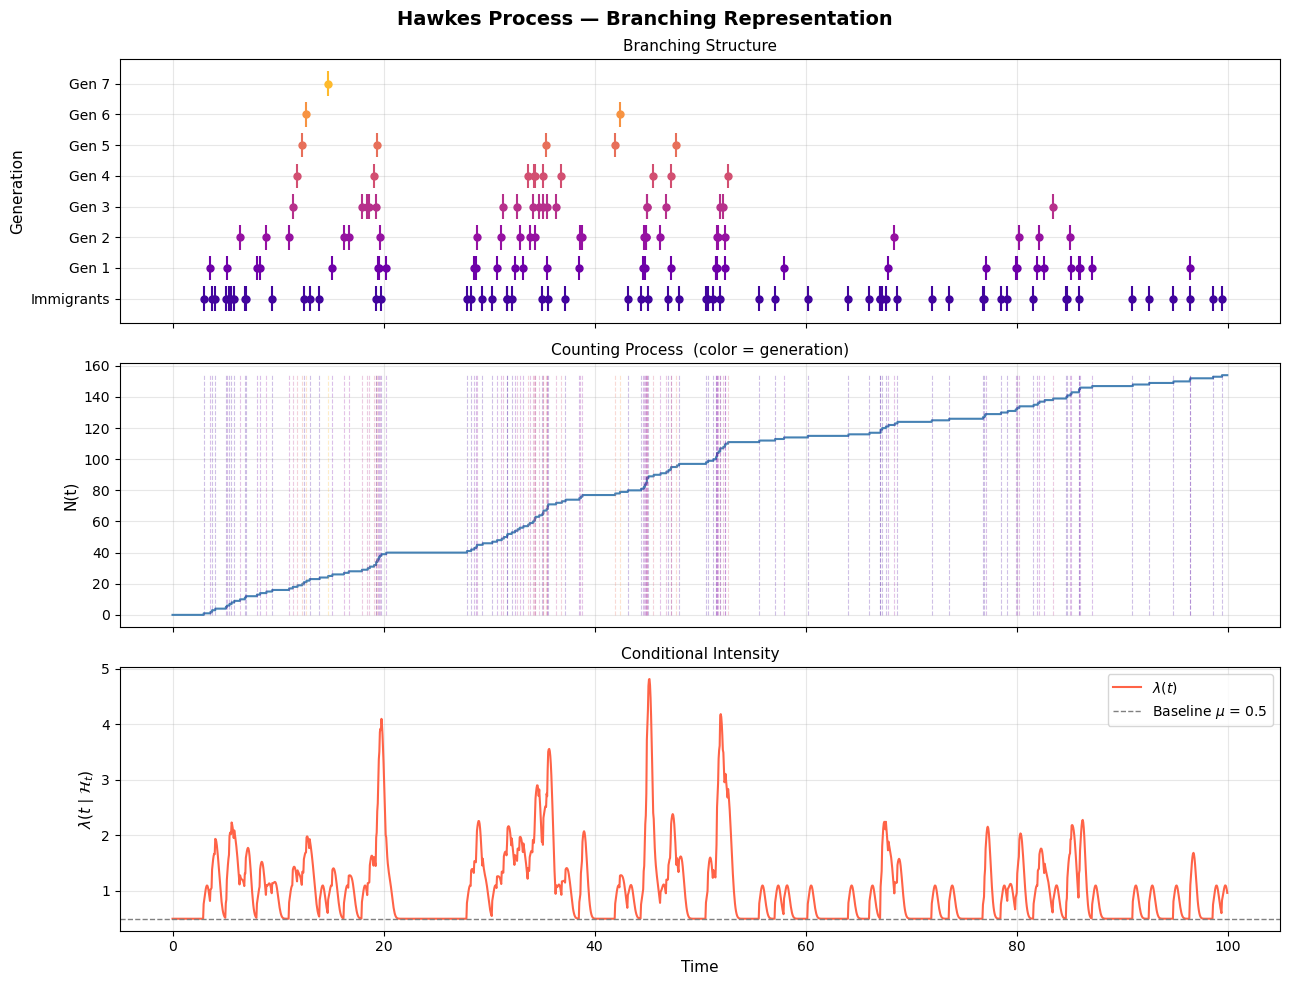

In [94]:
colors = plt.cm.plasma(np.linspace(0.1, 0.85, n_gen))

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
fig.suptitle("Hawkes Process — Branching Representation", fontsize=14, fontweight='bold')

ax = axes[0]
for t, g in all_events:
    ax.vlines(t, g - 0.4, g + 0.4, color=colors[g], linewidth=1.5)
    ax.scatter(t, g, color=colors[g], s=25, zorder=3)
ax.set_yticks(range(n_gen))
ax.set_yticklabels([f"Gen {i}" if i > 0 else "Immigrants" for i in range(n_gen)])
ax.set_ylabel("Generation", fontsize=11)
ax.set_title("Branching Structure", fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.step(time_grid, counting, where='post', color='steelblue', linewidth=1.5)
for t, g in all_events:
    ax.vlines(t, 0, counting.max(), color=colors[g], alpha=0.25, linewidth=0.8, linestyle='--')
ax.set_ylabel("N(t)", fontsize=11)
ax.set_title("Counting Process  (color = generation)", fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(time_grid, intensity, color='tomato', linewidth=1.5, label=r'$\lambda(t)$')
ax.axhline(mu0, color='gray', linestyle='--', linewidth=1, label=rf'Baseline $\mu$ = {mu0}')
ax.set_xlabel("Time", fontsize=11)
ax.set_ylabel(r"$\lambda(t \mid \mathcal{H}_t)$", fontsize=11)
ax.set_title("Conditional Intensity", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Pareto Kernel

In [95]:
%%time

T     = 100.0
mu0   = 0.5   
alpha = 0.6    
beta  = 1.0  

immigrants = sorted(np.random.uniform(0, T, np.random.poisson(mu0 * T)))

all_events  = [(t, 0) for t in immigrants]  
current_gen = immigrants

gen = 0
while len(current_gen) > 0:
    gen += 1
    next_gen = []
    for parent in current_gen:
        n_offspring = np.random.poisson(alpha)
        for _ in range(n_offspring):
            delay = np.random.exponential(1.0 / beta)
            child = parent + delay
            if child < T:
                next_gen.append(child)
                all_events.append((child, gen))
    current_gen = next_gen

all_events.sort(key=lambda x: x[0])
times       = np.array([e[0] for e in all_events])
generations = np.array([e[1] for e in all_events])
n_gen       = generations.max() + 1

CPU times: user 150 μs, sys: 9 μs, total: 159 μs
Wall time: 153 μs


In [96]:
%%time

p = 1.2

def nu(s):
    return alpha * (beta / (s + beta)) ** (p + 1)

def lambda_t(t):
    return mu0 + sum(nu(t - s) for s in times if s < t)

time_grid = np.arange(0, T, 0.05)
intensity = np.array([lambda_t(t) for t in time_grid])
counting  = np.searchsorted(times, time_grid, side='right')

CPU times: user 24 ms, sys: 799 μs, total: 24.8 ms
Wall time: 24.4 ms


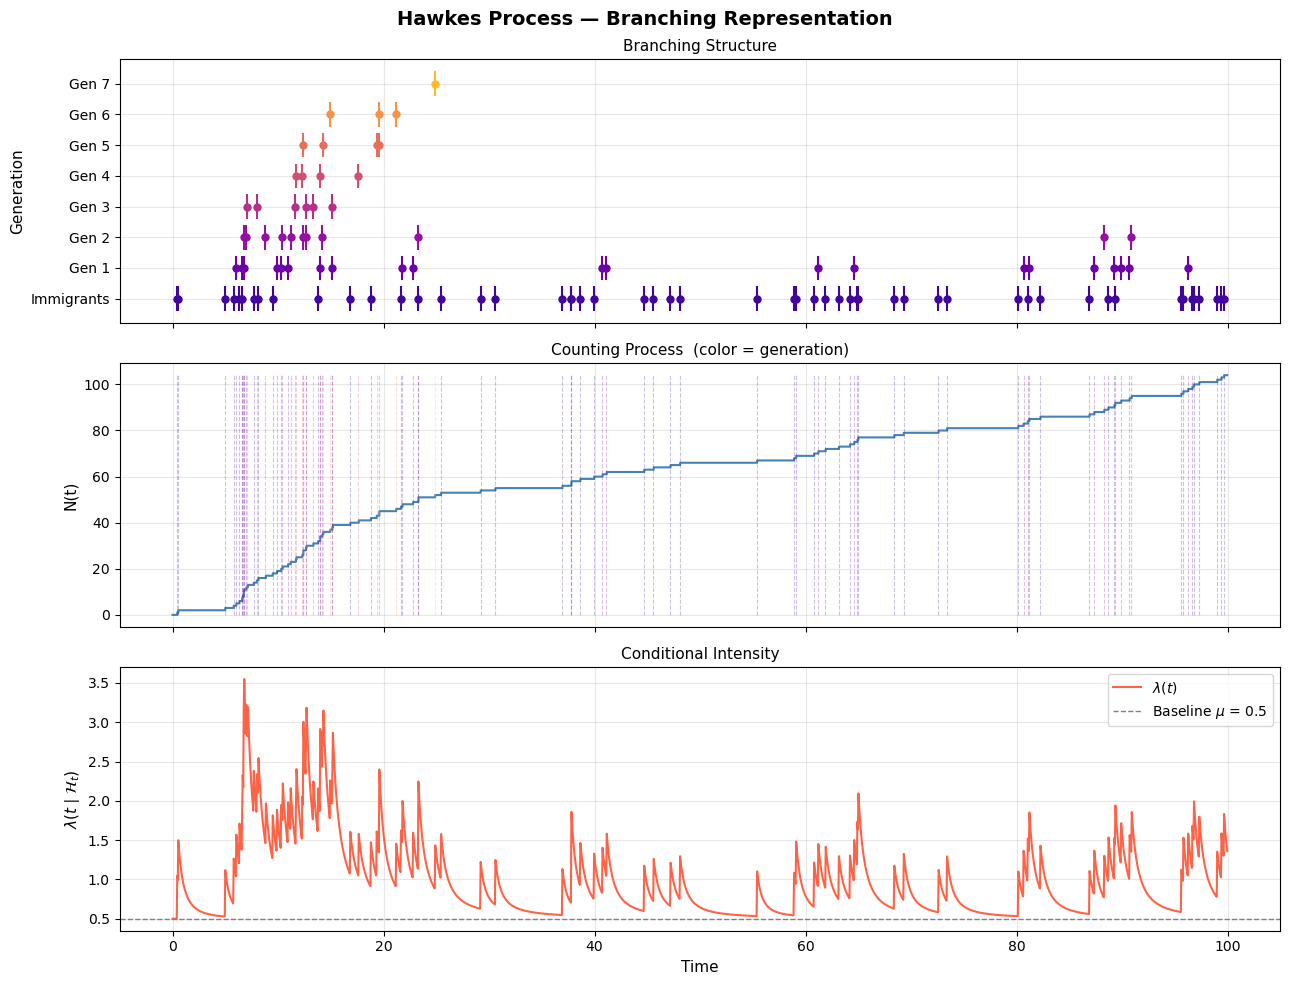

In [97]:
colors = plt.cm.plasma(np.linspace(0.1, 0.85, n_gen))

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
fig.suptitle("Hawkes Process — Branching Representation", fontsize=14, fontweight='bold')

ax = axes[0]
for t, g in all_events:
    ax.vlines(t, g - 0.4, g + 0.4, color=colors[g], linewidth=1.5)
    ax.scatter(t, g, color=colors[g], s=25, zorder=3)
ax.set_yticks(range(n_gen))
ax.set_yticklabels([f"Gen {i}" if i > 0 else "Immigrants" for i in range(n_gen)])
ax.set_ylabel("Generation", fontsize=11)
ax.set_title("Branching Structure", fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.step(time_grid, counting, where='post', color='steelblue', linewidth=1.5)
for t, g in all_events:
    ax.vlines(t, 0, counting.max(), color=colors[g], alpha=0.25, linewidth=0.8, linestyle='--')
ax.set_ylabel("N(t)", fontsize=11)
ax.set_title("Counting Process  (color = generation)", fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(time_grid, intensity, color='tomato', linewidth=1.5, label=r'$\lambda(t)$')
ax.axhline(mu0, color='gray', linestyle='--', linewidth=1, label=rf'Baseline $\mu$ = {mu0}')
ax.set_xlabel("Time", fontsize=11)
ax.set_ylabel(r"$\lambda(t \mid \mathcal{H}_t)$", fontsize=11)
ax.set_title("Conditional Intensity", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Comparing the time it takes for the two algorithms to generate the simulations for the different kernel we can state that the Thining algorithm is faster but possess a strong limitation for the "Power-Law" kernel. This limitation is due to mathematical reasons. As the Power-Law combine a large initial spike with a very slow decay, the computer find it hard to compute the upper bound and struggle with it. On the other hand, the branching algorithm also posssess a limitation. As this ratio approach one, the process become "critical" and the algorithm will struggle. 
